In [1]:
pip install --upgrade mlflow dagshub optuna gensim scikit-learn scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import dagshub
dagshub.init(repo_owner='Yaxh8074', repo_name='sentiment-analysis-of-yt-comment', mlflow=True)

Accessing as Yaxh8074

Initialized MLflow to track repo "Yaxh8074/sentiment-analysis-of-yt-comment"

Repository Yaxh8074/sentiment-analysis-of-yt-comment initialized!

In [3]:
import mlflow
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

#from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('..\preprocessed_data.csv').dropna(subset=['comment'])
df.shape

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\krish\AppData\Local\Temp\ipykernel_24020\3370416756.py:1: SyntaxWarning: invalid escape sequence '\p'
  df = pd.read_csv('..\preprocessed_data.csv').dropna(subset=['comment'])


(36662, 5)

In [5]:
# Set or create an experiment
mlflow.set_experiment("Exp 2 - BoW vs TfIdf")

<Experiment: artifact_location='mlflow-artifacts:/237ffdf86fc9483faf12d5726740f5cb', creation_time=1772427059516, experiment_id='3', last_update_time=1772427059516, lifecycle_stage='active', name='Exp 2 - BoW vs TfIdf', tags={}, workspace='default'>

In [6]:
# Function to vectorize data
def vectorize_data(X_train, X_test, vectorizer_type, ngram_range, max_features):
    if vectorizer_type == 'bow':
        vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=max_features)
    elif vectorizer_type == 'tfidf':
        vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=max_features)

    X_train_vec = vectorizer.fit_transform(X_train['comment']).toarray()
    X_test_vec = vectorizer.transform(X_test['comment']).toarray()

    return X_train_vec, X_test_vec

In [7]:
# Objective function for Optuna
def objective(trial):
    # Split data
    X = df[['comment', 'word_count', 'char_count', 'avg_word_length']]
    y = df['category']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Suggest hyperparameters
    vectorizer_type = trial.suggest_categorical("vectorizer_type", ["bow", "tfidf"])
    ngram_range_str = trial.suggest_categorical("ngram_range", ["(1, 1)", "(1, 2)", "(1, 3)"])
    ngram_range = eval(ngram_range_str)
    max_features = trial.suggest_int("max_features", 1000, 10000)

    # Vectorize data
    X_train_vec, X_test_vec = vectorize_data(X_train, X_test, vectorizer_type, ngram_range, max_features)

    # Combine additional features
    X_train_combined = np.hstack([X_train_vec, X_train[['word_count', 'char_count', 'avg_word_length']].values])
    X_test_combined = np.hstack([X_test_vec, X_test[['word_count', 'char_count', 'avg_word_length']].values])

    # Train a RandomForest model
    model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
    model.fit(X_train_combined, y_train)

    # Make predictions
    y_pred = model.predict(X_test_combined)
    accuracy = accuracy_score(y_test, y_pred)

    # Log each run with MLflow
    with mlflow.start_run() as run:
        # Set run name
        mlflow.set_tag("mlflow.runName", f"{ngram_range_str}_{vectorizer_type}_{max_features}")

        mlflow.log_param("vectorizer_type", vectorizer_type)
        mlflow.log_param("ngram_range", ngram_range)
        mlflow.log_param("max_features", max_features)

        # Log model metrics
        mlflow.log_metric("accuracy", accuracy)

        # Logging the classification report
        classification_rep = classification_report(y_test, y_pred, output_dict=True)
        for label, metrics in classification_rep.items():
            if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
                for metric, value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric}", value)

        # Confusion matrix plot
        conf_matrix = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")

        # Save and log the confusion matrix plot
        plt.savefig("confusion_matrix.png")
        mlflow.log_artifact("confusion_matrix.png")

    return accuracy

[I 2026-03-02 10:23:54,837] A new study created in memory with name: Bow vs TFIDF


🏃 View run (1, 3)_tfidf_2792 at: https://dagshub.com/Yaxh8074/sentiment-analysis-of-yt-comment.mlflow/#/experiments/3/runs/31eb86f9f48c4d3d985113b0838c51b6
🧪 View experiment at: https://dagshub.com/Yaxh8074/sentiment-analysis-of-yt-comment.mlflow/#/experiments/3


[I 2026-03-02 10:25:25,855] Trial 0 finished with value: 0.618164462021001 and parameters: {'vectorizer_type': 'tfidf', 'ngram_range': '(1, 3)', 'max_features': 2792}. Best is trial 0 with value: 0.618164462021001.


🏃 View run (1, 3)_tfidf_4586 at: https://dagshub.com/Yaxh8074/sentiment-analysis-of-yt-comment.mlflow/#/experiments/3/runs/af20a371a9c64097a453af4beb841ad6
🧪 View experiment at: https://dagshub.com/Yaxh8074/sentiment-analysis-of-yt-comment.mlflow/#/experiments/3


[I 2026-03-02 10:27:34,894] Trial 1 finished with value: 0.6095731624164735 and parameters: {'vectorizer_type': 'tfidf', 'ngram_range': '(1, 3)', 'max_features': 4586}. Best is trial 0 with value: 0.618164462021001.


...

🏃 View run (1, 2)_tfidf_7181 at: https://dagshub.com/Yaxh8074/sentiment-analysis-of-yt-comment.mlflow/#/experiments/3/runs/949d712de9c44f1790b5e5a3db7eaf92
🧪 View experiment at: https://dagshub.com/Yaxh8074/sentiment-analysis-of-yt-comment.mlflow/#/experiments/3


[I 2026-03-02 11:27:57,156] Trial 37 finished with value: 0.6087549434065185 and parameters: {'vectorizer_type': 'tfidf', 'ngram_range': '(1, 2)', 'max_features': 7181}. Best is trial 13 with value: 0.6345288422201009.


🏃 View run (1, 2)_bow_2120 at: https://dagshub.com/Yaxh8074/sentiment-analysis-of-yt-comment.mlflow/#/experiments/3/runs/2efc3294e66d42139a92abb1fafeeb15
🧪 View experiment at: https://dagshub.com/Yaxh8074/sentiment-analysis-of-yt-comment.mlflow/#/experiments/3


[I 2026-03-02 11:29:06,438] Trial 38 finished with value: 0.618982681030956 and parameters: {'vectorizer_type': 'bow', 'ngram_range': '(1, 2)', 'max_features': 2120}. Best is trial 13 with value: 0.6345288422201009.
[W 2026-03-02 11:29:23,181] Trial 39 failed with parameters: {'vectorizer_type': 'tfidf', 'ngram_range': '(1, 3)', 'max_features': 9548} because of the following error: MemoryError((29329, 9551), dtype('float32')).
Traceback (most recent call last):
  File "C:\Users\krish\AppData\Roaming\Python\Python312\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\krish\AppData\Local\Temp\ipykernel_24020\859482370.py", line 23, in objective
    model.fit(X_train_combined, y_train)
  File "C:\Users\krish\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1336, in wrapper
    >>> estimator = MyEstimator().fit(X, y)
                       ^^^^^^^^^^^^^^^^^^^^^
  File "C

MemoryError: Unable to allocate 1.04 GiB for an array with shape (29329, 9551) and data type float32

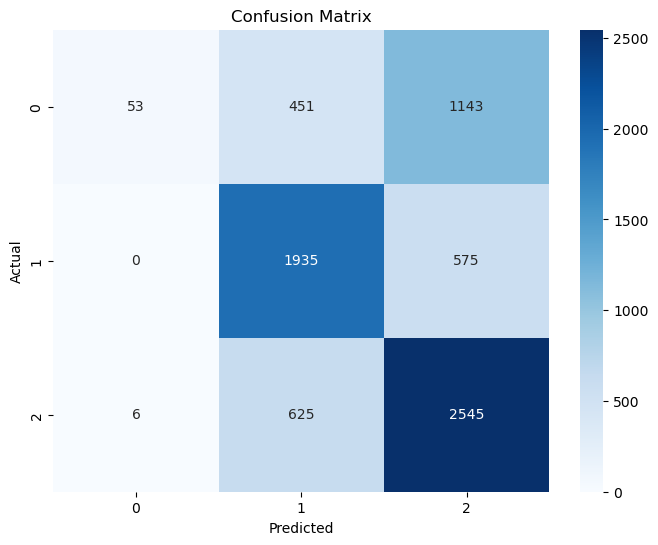

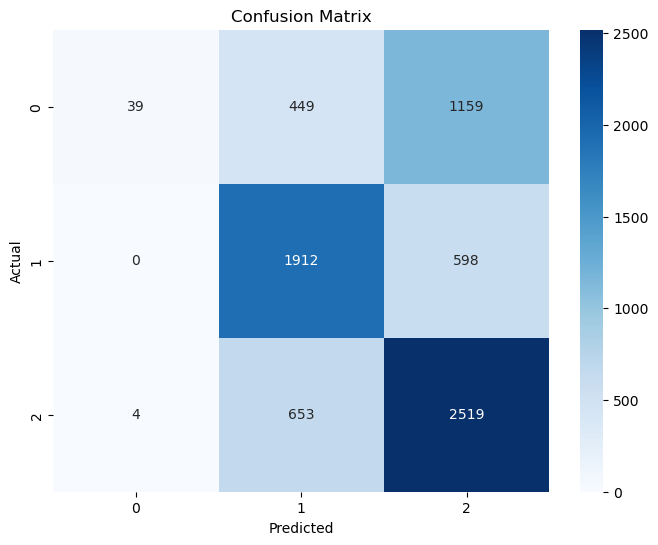

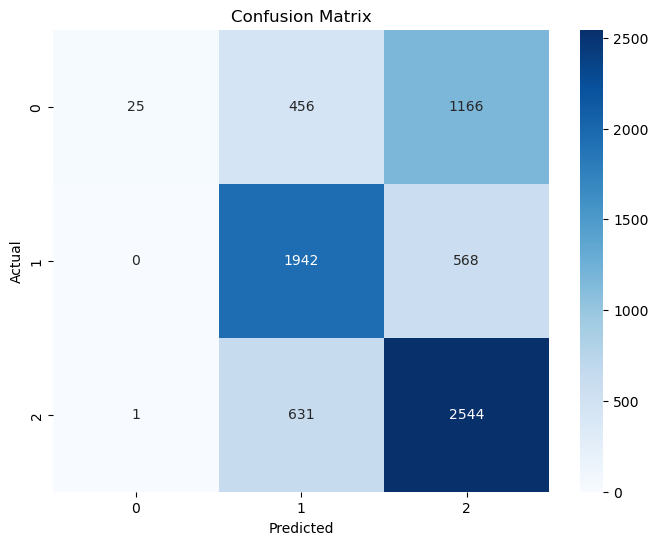

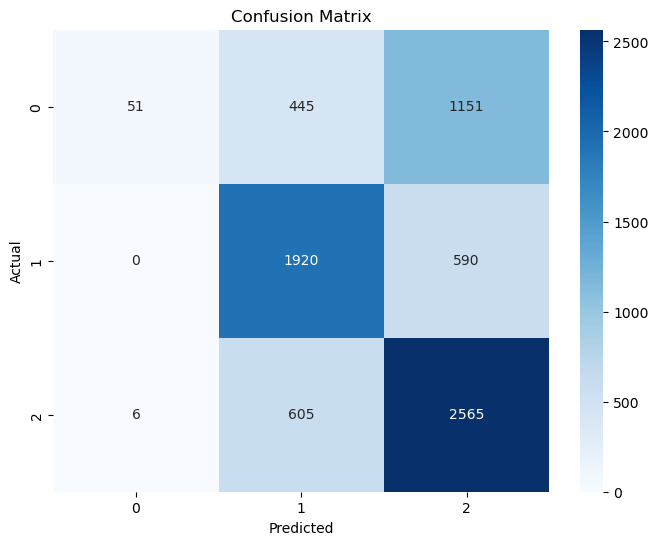

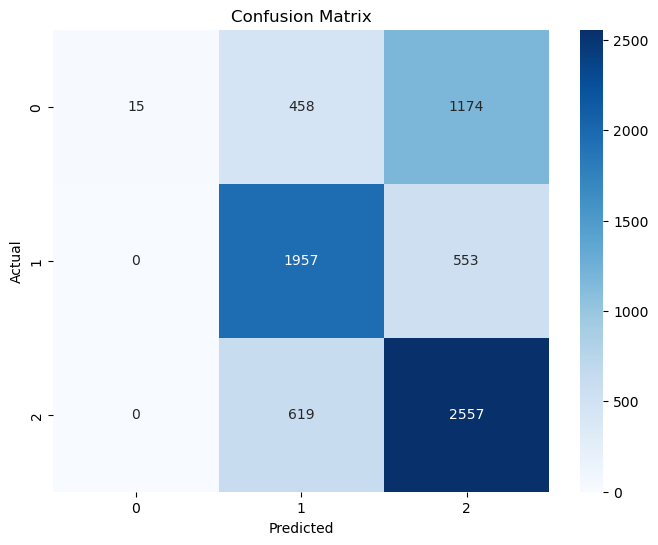

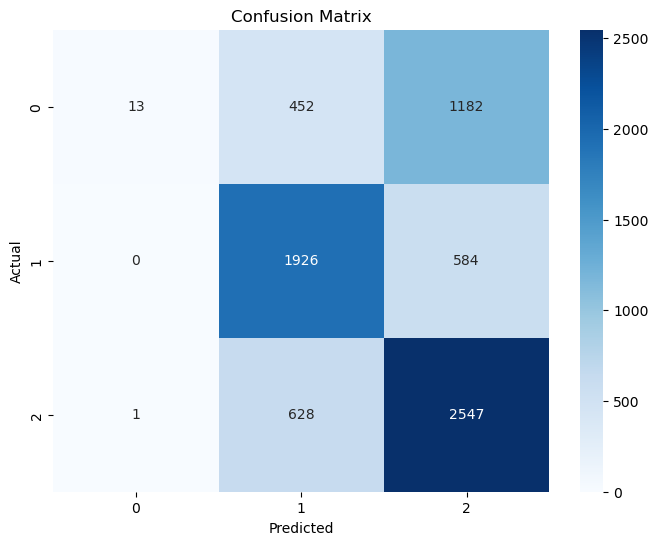

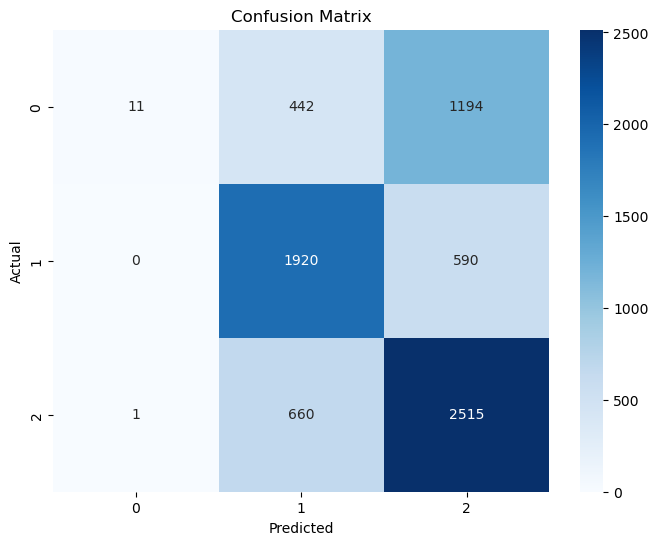

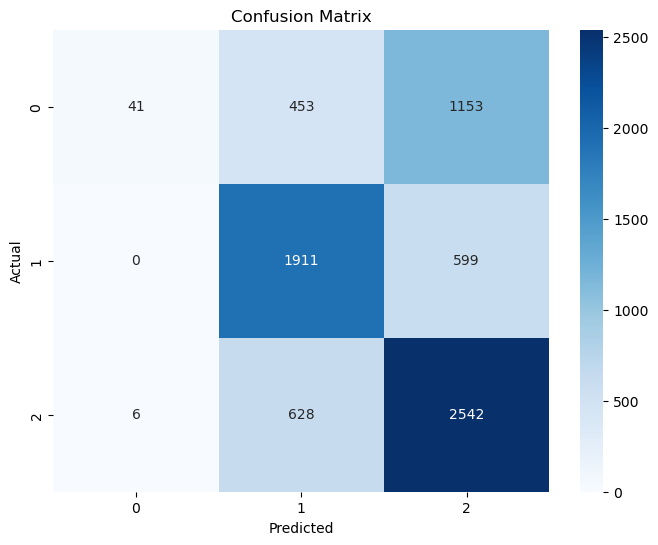

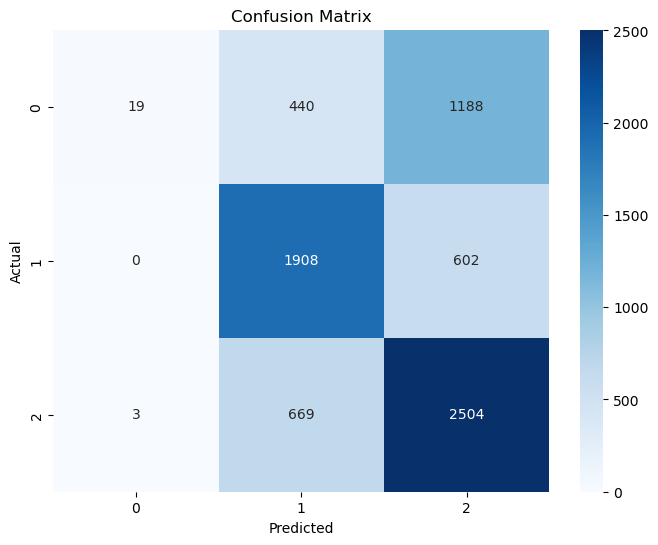

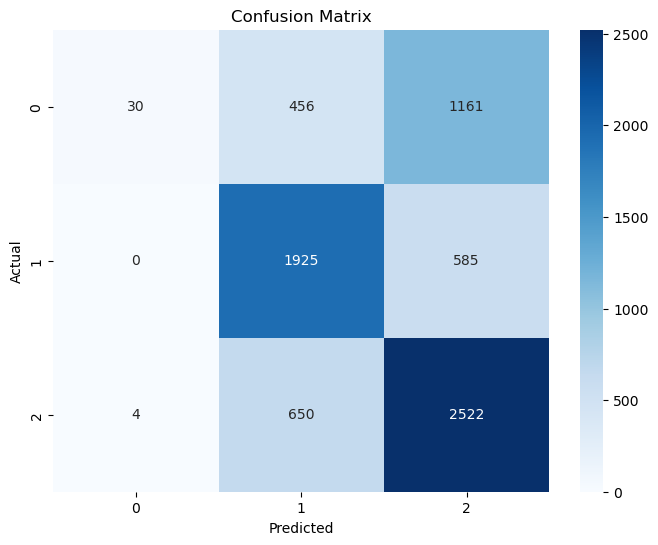

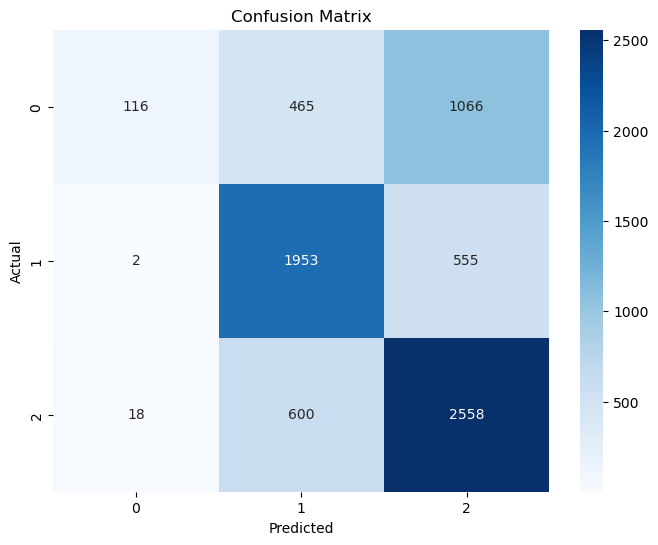

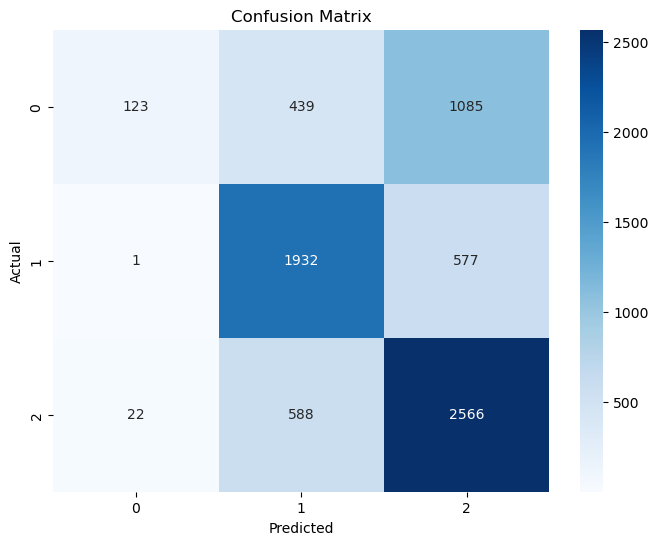

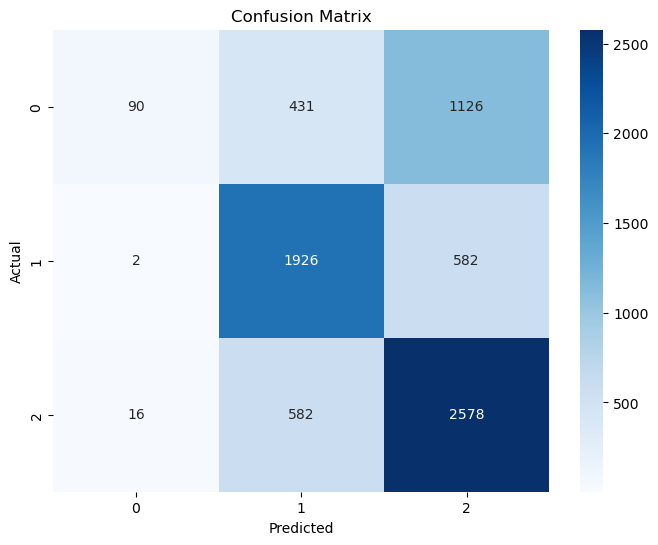

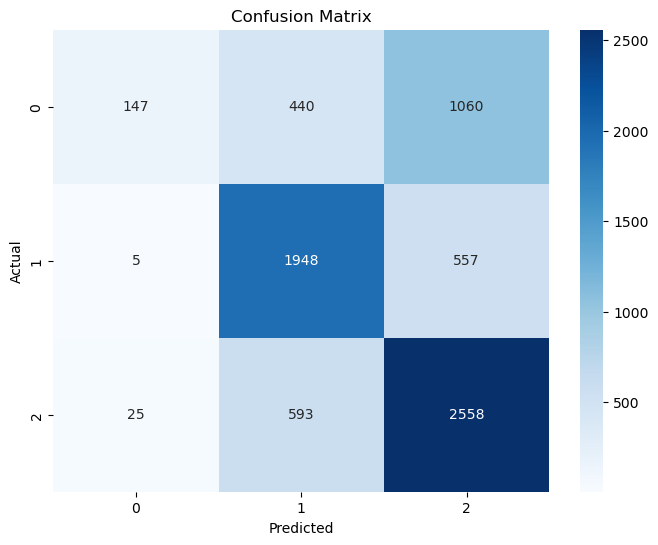

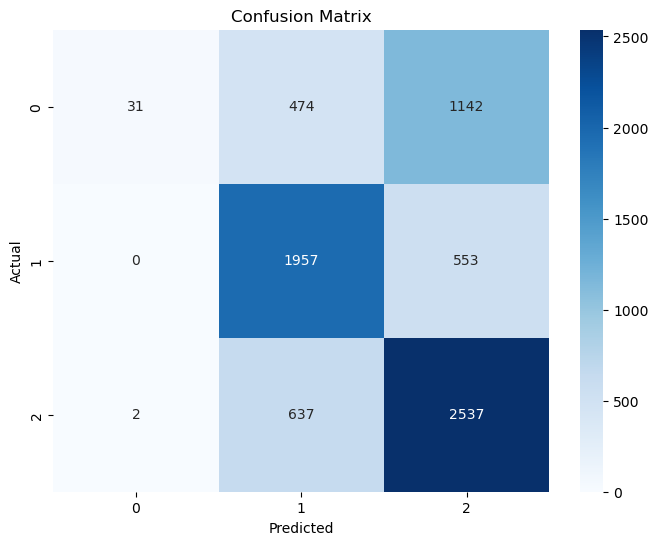

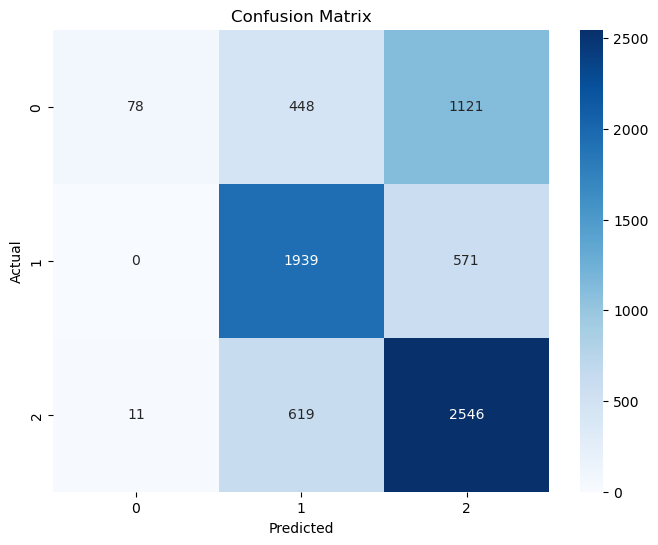

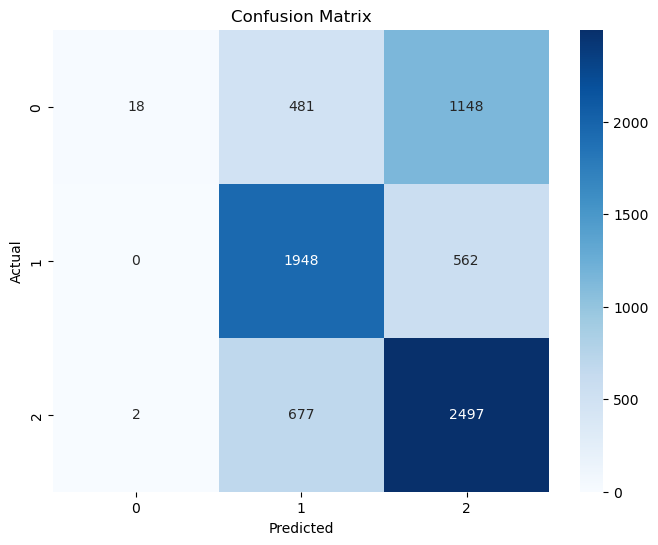

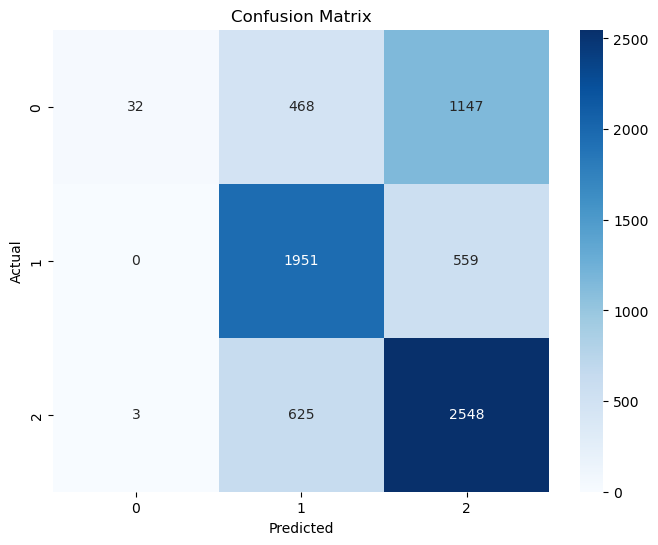

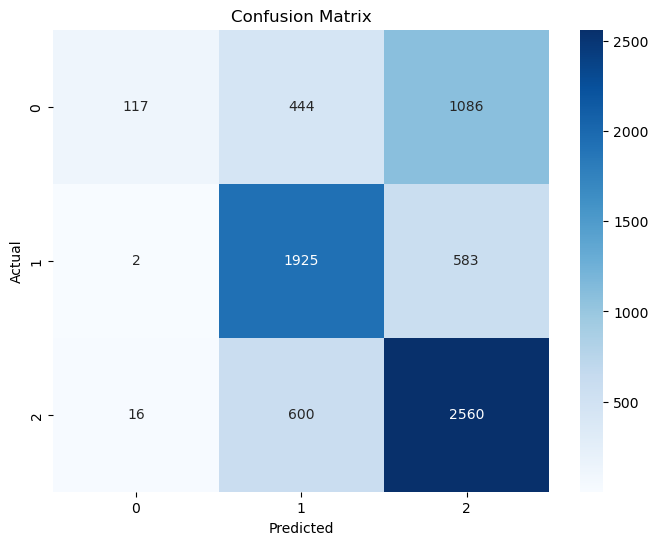

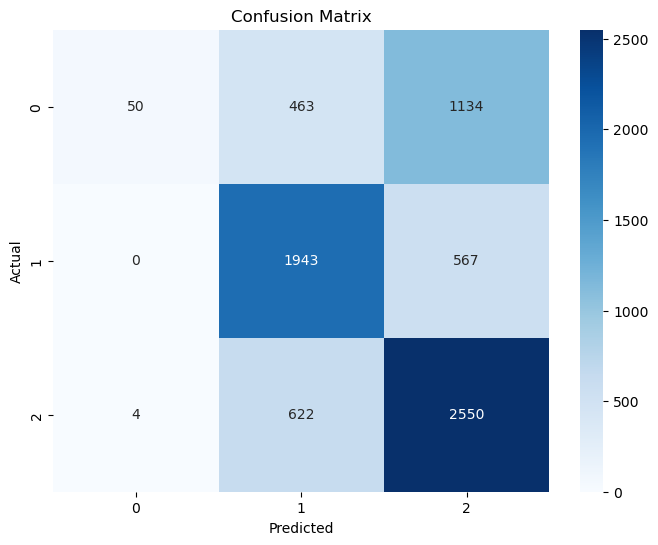

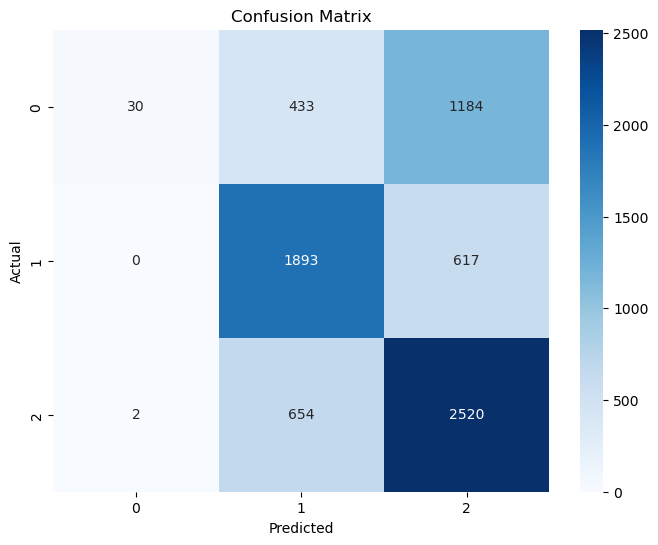

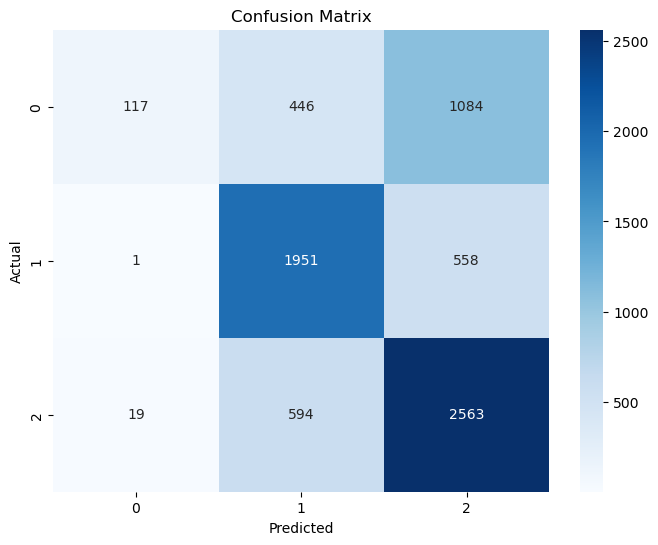

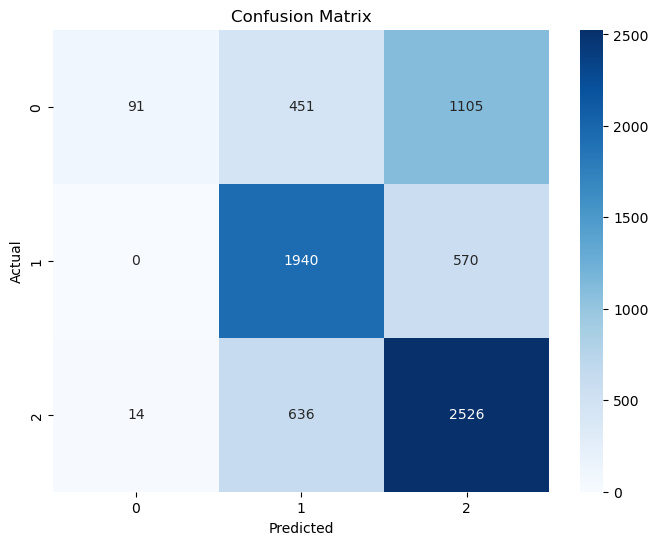

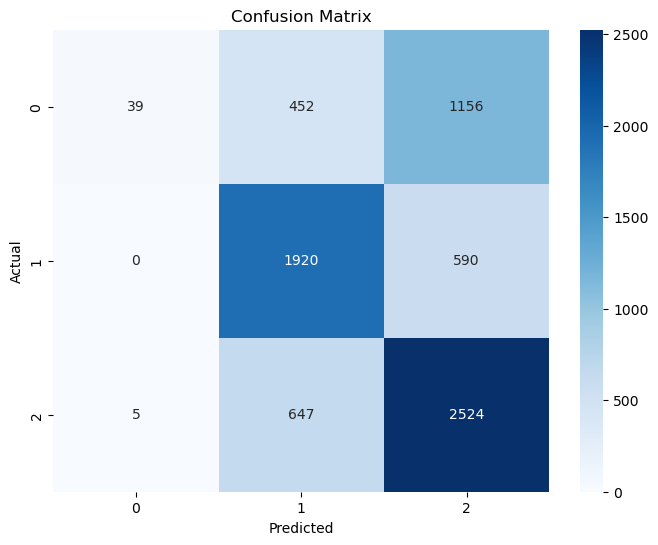

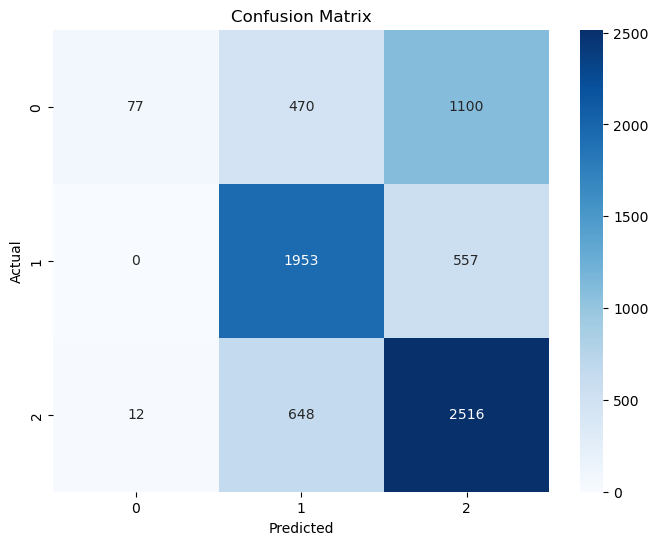

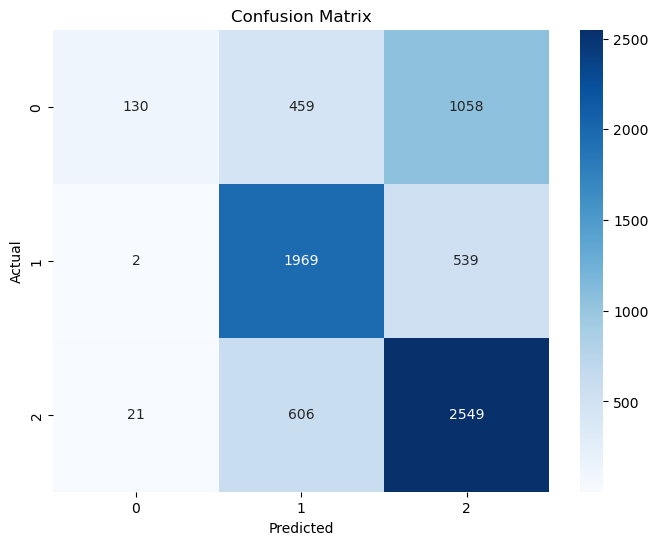

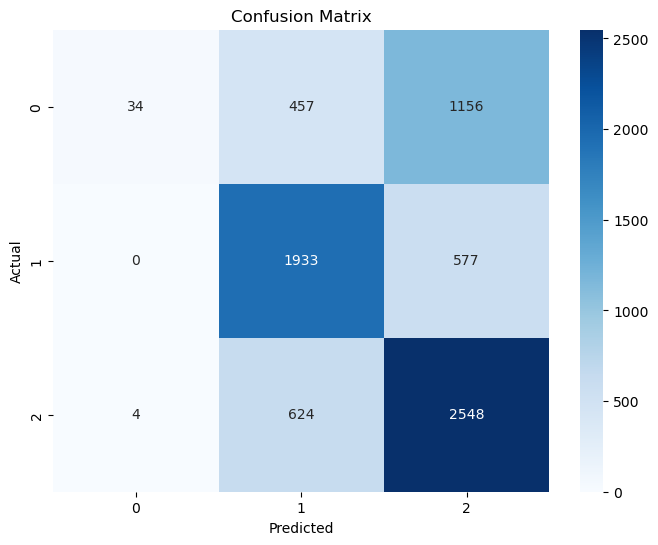

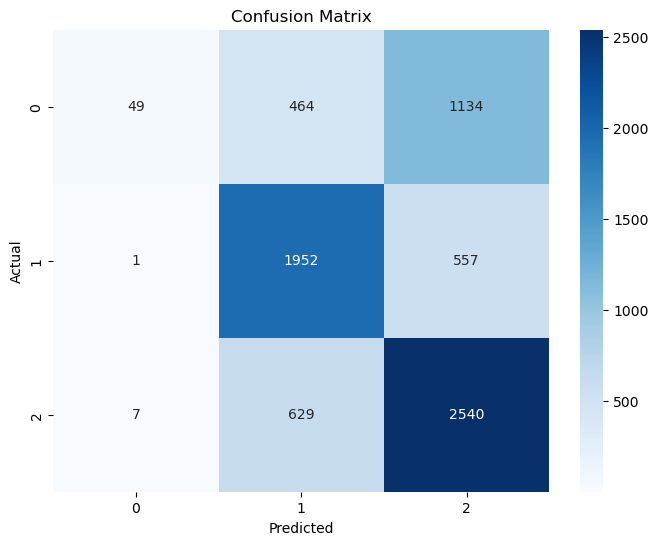

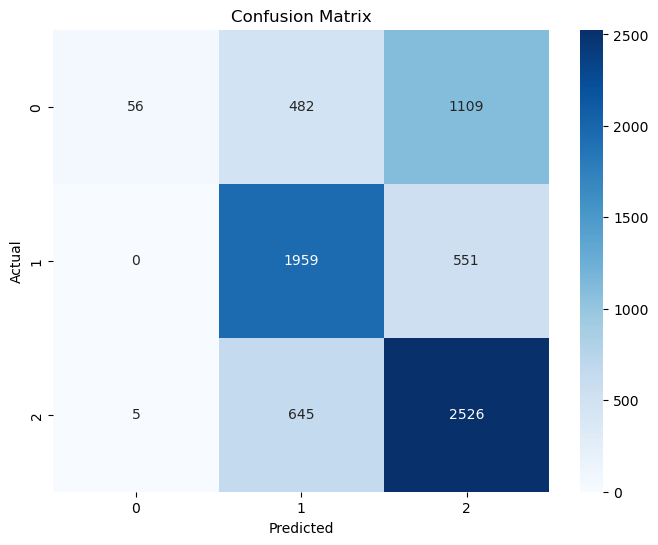

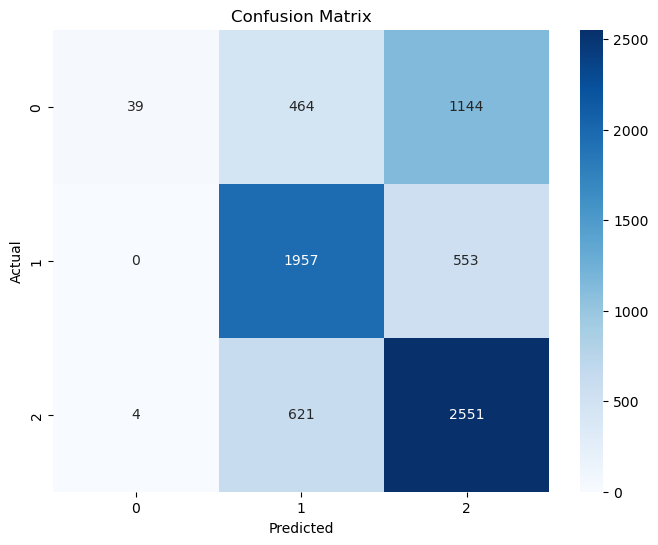

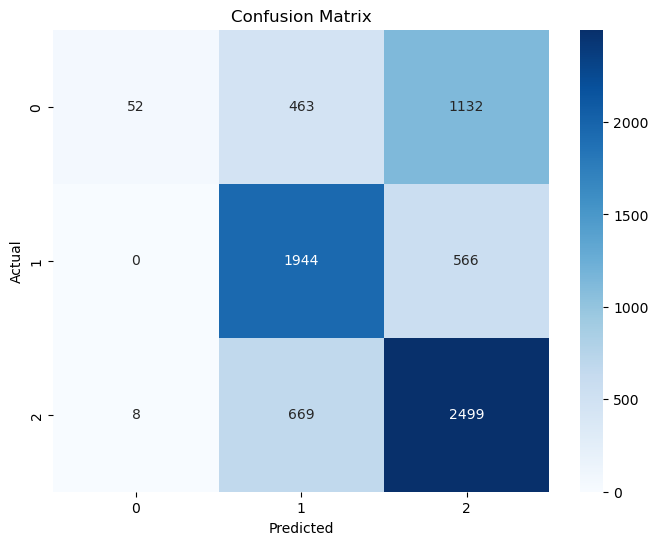

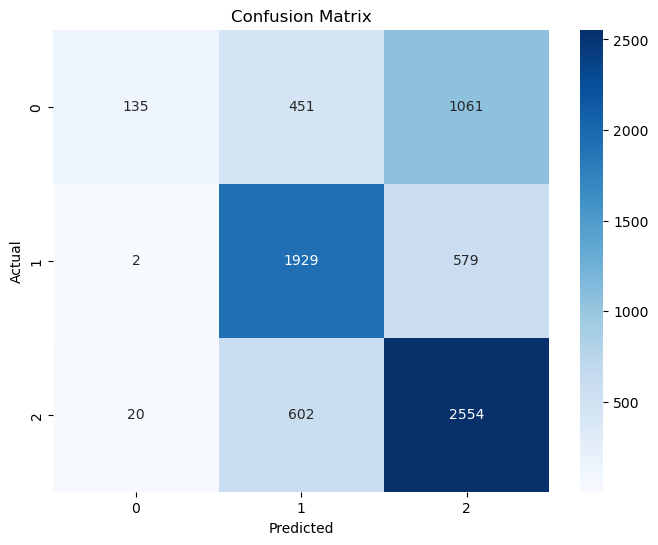

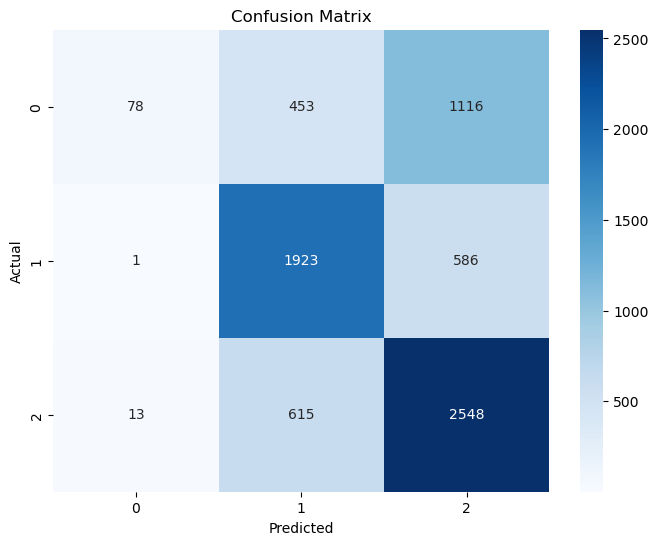

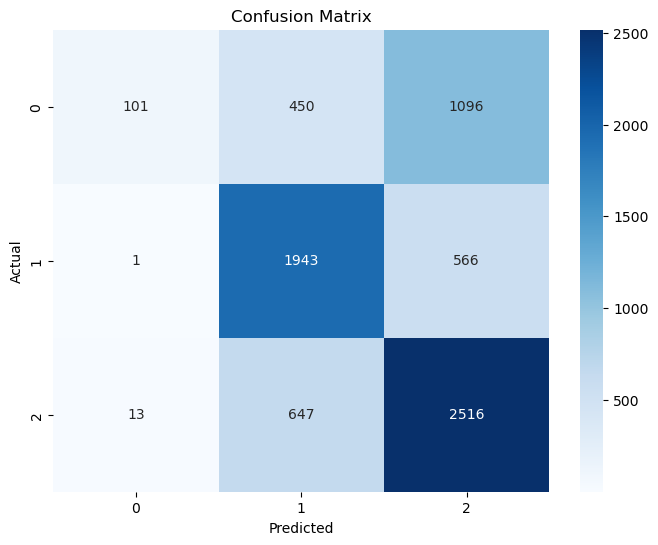

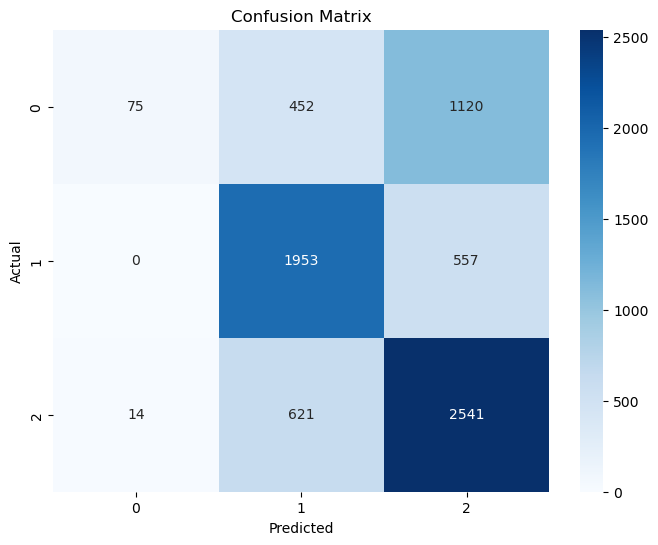

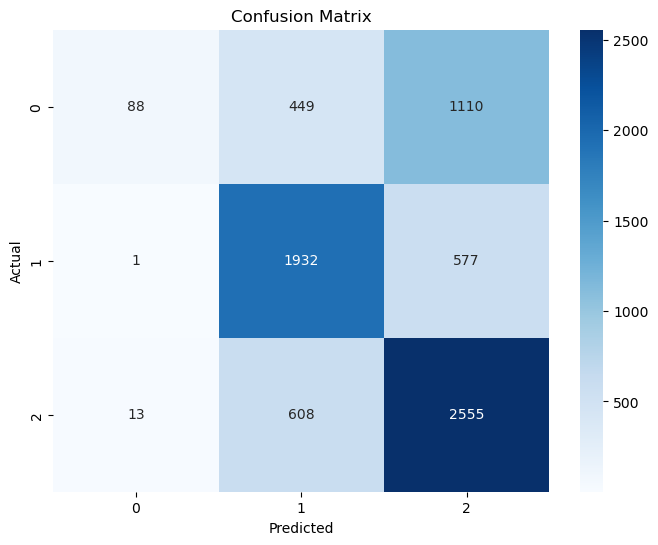

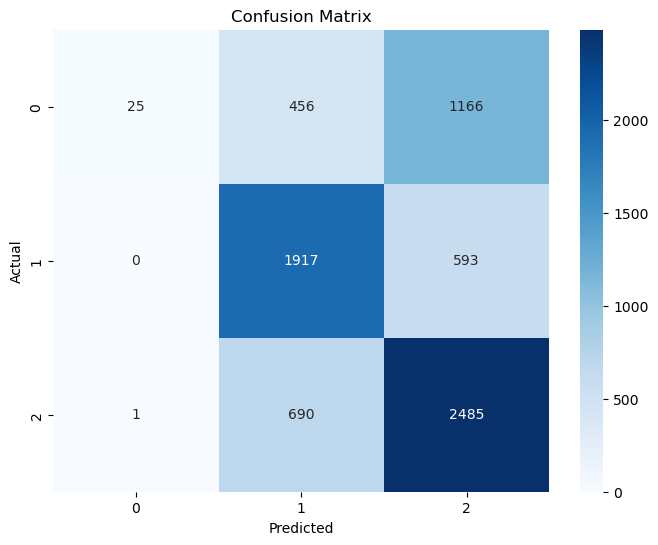

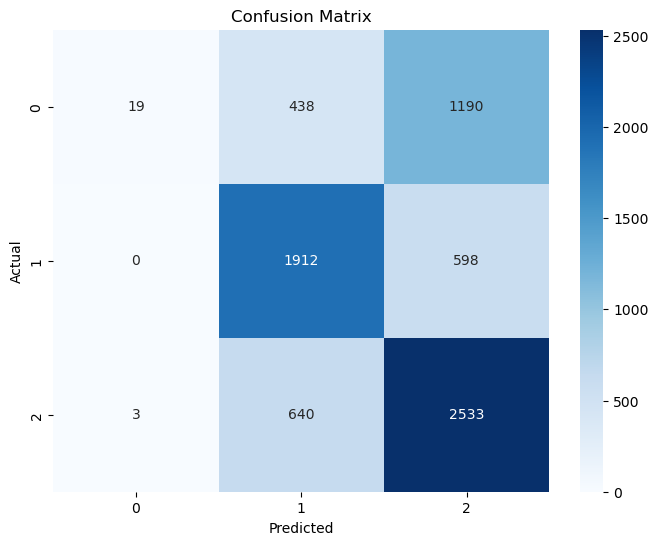

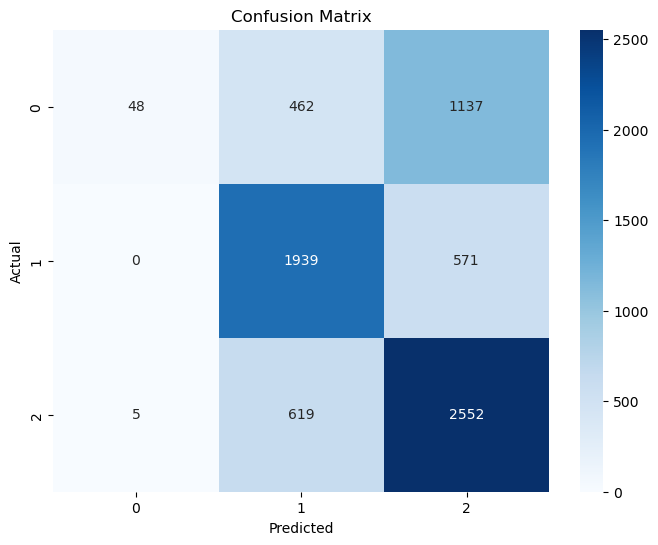

In [8]:
# Running Optuna
study = optuna.create_study(direction="maximize", study_name='Bow vs TFIDF')
study.optimize(objective, n_trials=200)

In [ ]:
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.6429837719896359
Best hyperparameters: {'vectorizer_type': 'tfidf', 'ngram_range': '(1, 2)', 'max_features': 1006}
